# 01 Preprocessing

In [7]:
import matplotlib.pyplot as plt

from plant_disease.config import SELECTED_DATA_DIR
from plant_disease.stage1_preproc import ImagePreprocessor
from plant_disease.utils.color import bgr_to_hsv, bgr_to_rgb
from plant_disease.utils.io import load_image

plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["image.interpolation"] = "nearest"

preprocessor = ImagePreprocessor()

In [8]:
extensoes_validas = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

diretorio_imagens = SELECTED_DATA_DIR

pastas_preferidas = [
    "potato_healthy",
    "tomato_healthy",
    "potato_early_blight",
    "potato_late_blight",
    "tomato_early_blight",
    "tomato_late_blight",
]


def selecionar_imagens_teste(diretorio_base, pastas, limite=5):
    caminhos = []

    for nome_pasta in pastas:
        pasta = diretorio_base / nome_pasta

        if not pasta.exists():
            continue

        for arquivo in sorted(pasta.iterdir()):
            if arquivo.suffix.lower() in extensoes_validas:
                caminhos.append(arquivo)
                break

        if len(caminhos) >= limite:
            return caminhos

    if len(caminhos) < limite:
        for arquivo in sorted(diretorio_base.rglob("*")):
            if (
                arquivo.suffix.lower() in extensoes_validas
                and arquivo not in caminhos
            ):
                caminhos.append(arquivo)

            if len(caminhos) >= limite:
                break

    return caminhos


caminhos_teste = selecionar_imagens_teste(
    diretorio_imagens,
    pastas_preferidas,
    limite=5,
)

print("Imagens selecionadas:")

for caminho in caminhos_teste:
    print("-", caminho.name)

if len(caminhos_teste) < 5:
    print("Aviso: não foram encontradas 5 imagens; usando o máximo disponível.")

Imagens selecionadas:
- 0be9d721-82f5-42c3-b535-7494afe01dbe___RS_HL 1814.JPG
- 003944fc-3b99-4a0f-9ed4-0e07352fd8b3___RS_HL 9844.JPG
- 00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG
- 0085ef03-aec3-431a-99a1-de286e10c0cf___RS_LB 2949.JPG
- 00c5c908-fc25-4710-a109-db143da23112___RS_Erly.B 7778.JPG


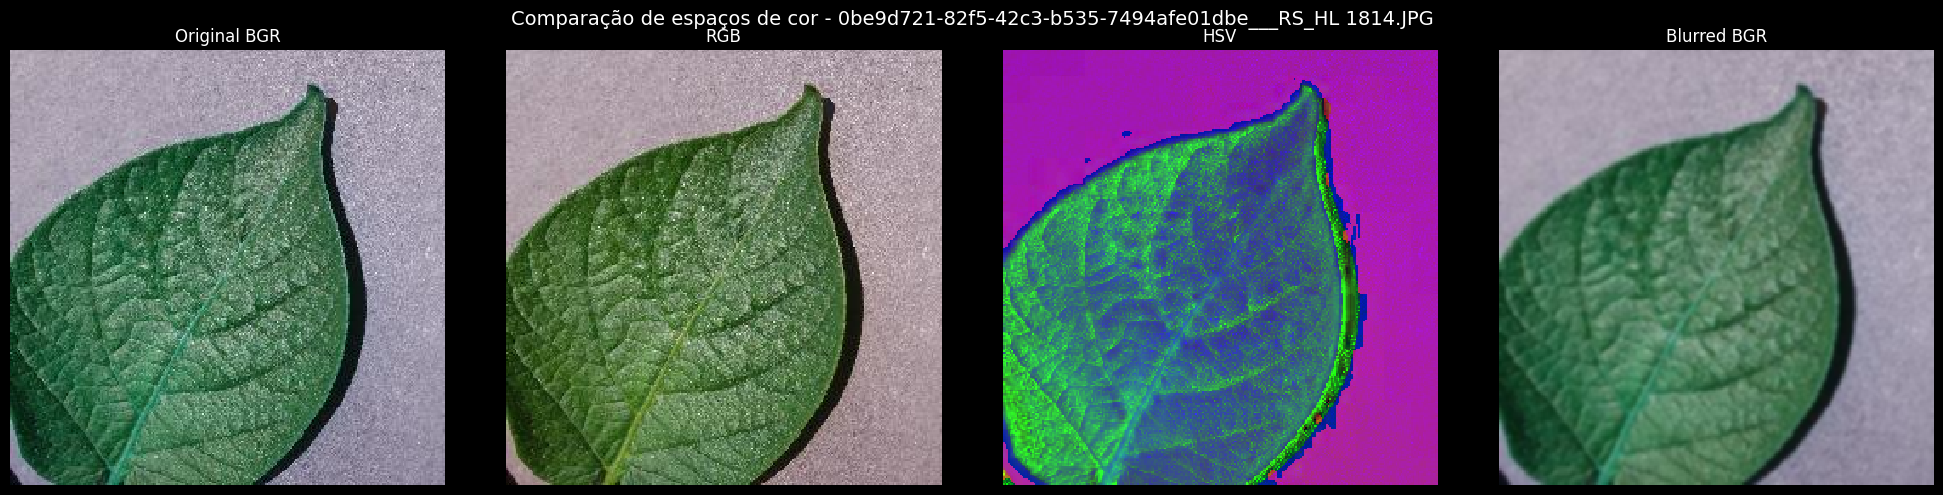

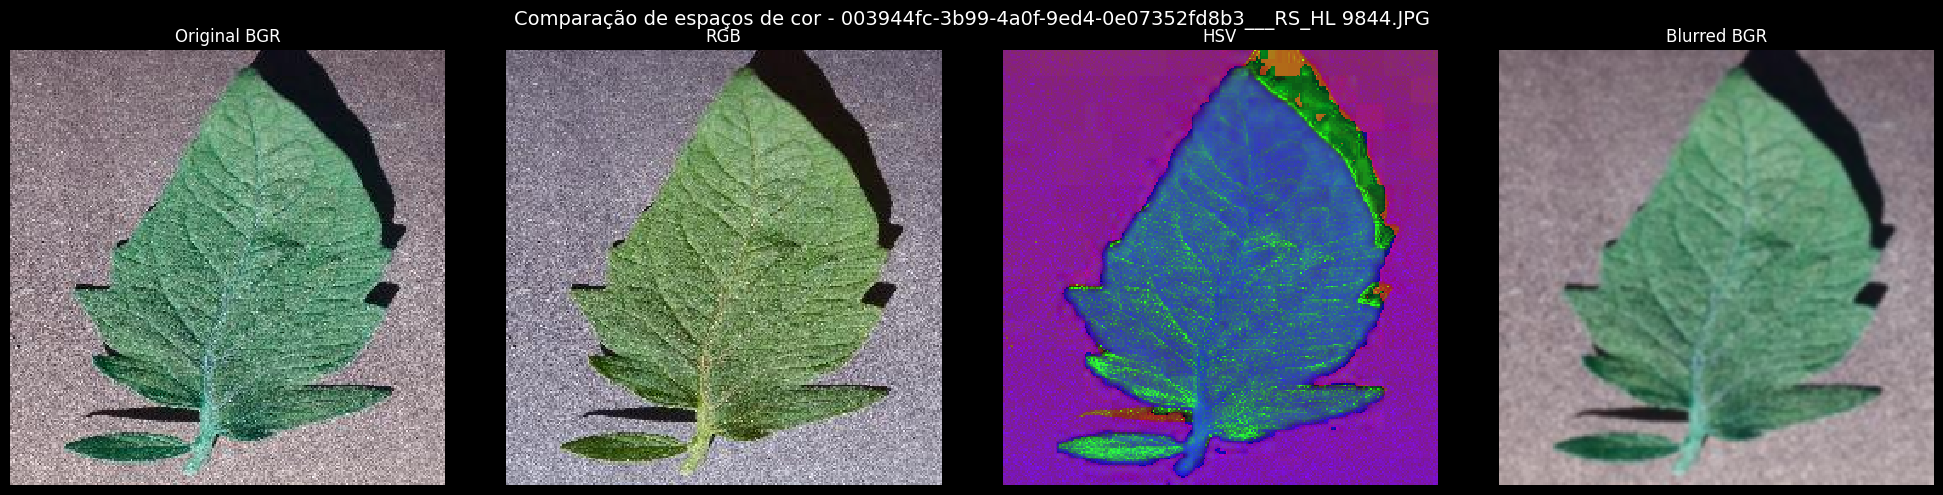

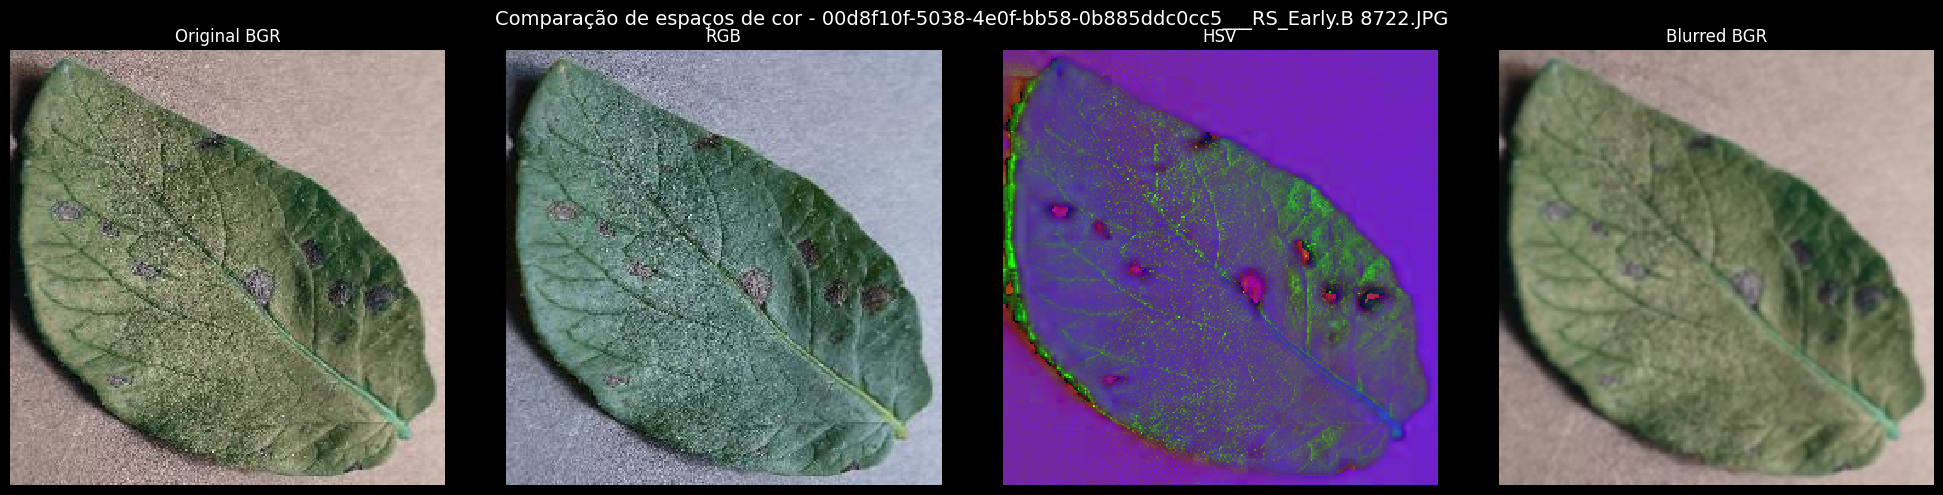

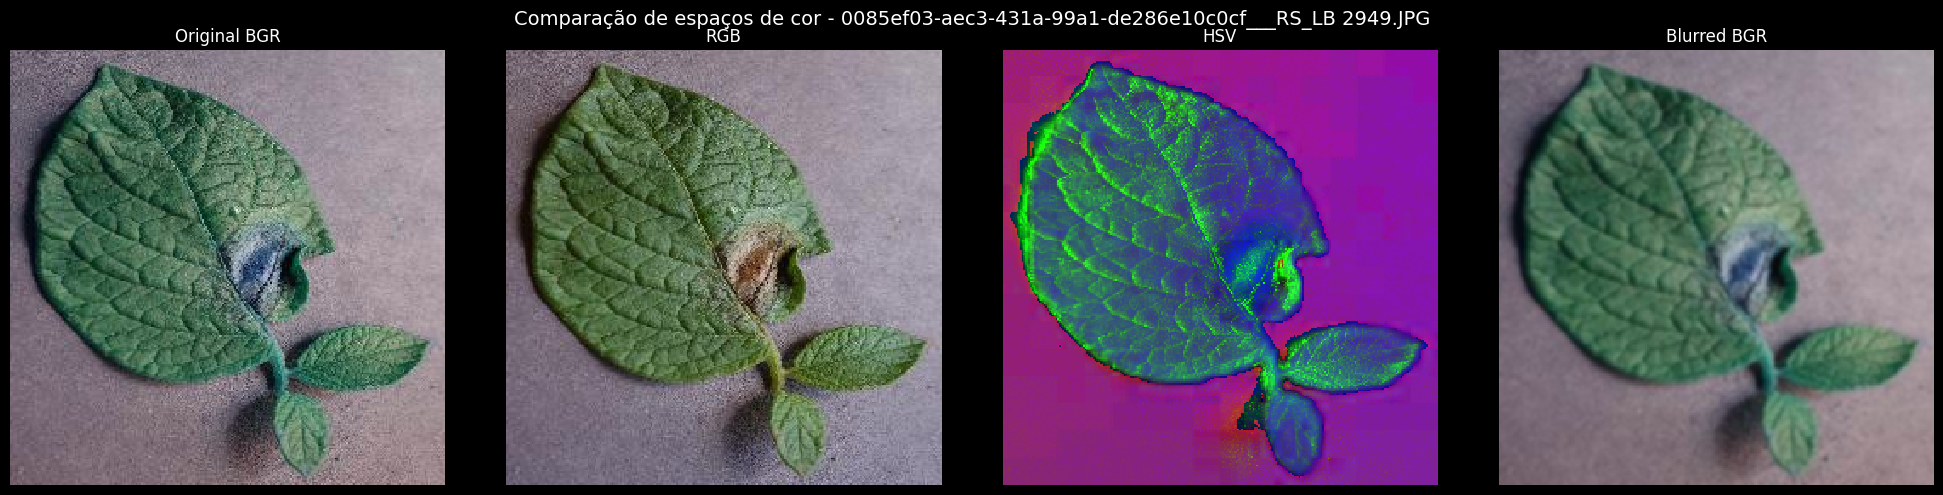

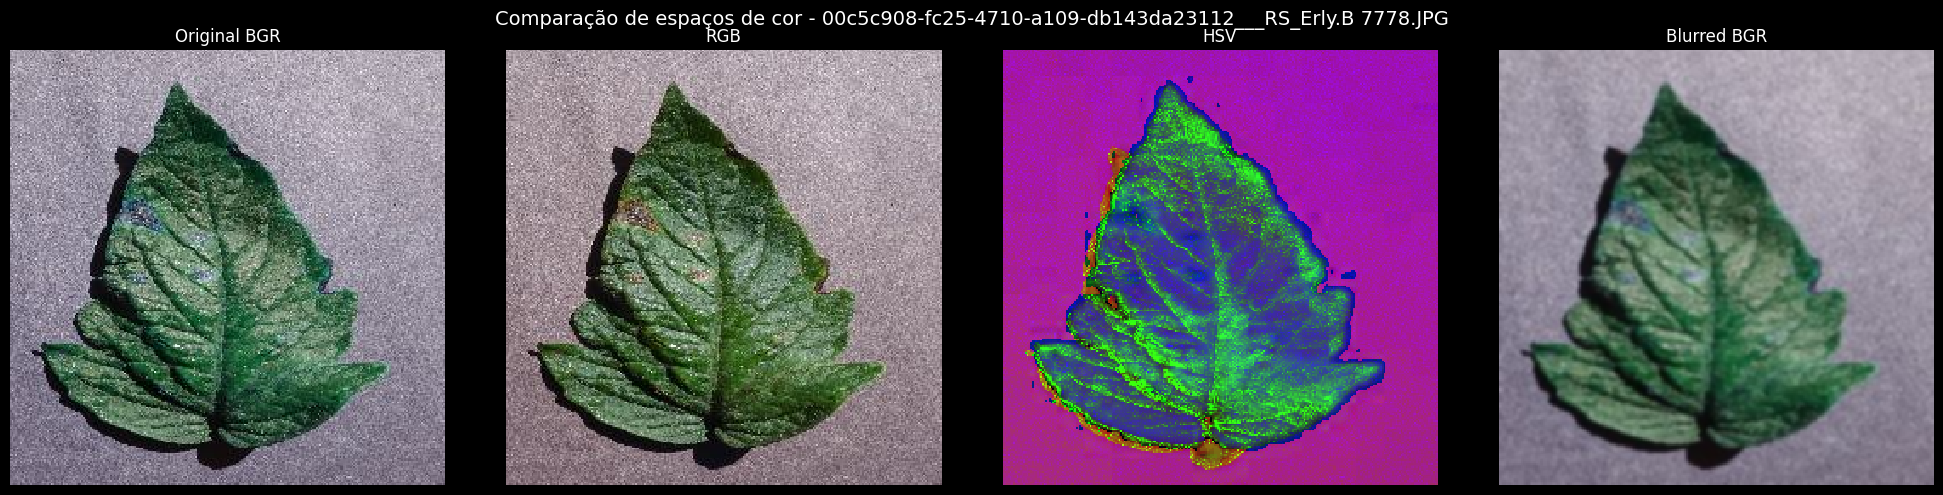

In [9]:
def mostrar_comparacao(caminho_imagem):
    imagem_bgr = load_image(str(caminho_imagem))

    if imagem_bgr is None:
        print(f"Não foi possível carregar: {caminho_imagem}")
        return

    imagem_rgb = bgr_to_rgb(imagem_bgr)
    imagem_hsv = bgr_to_hsv(imagem_bgr)
    imagem_suave = preprocessor.run(imagem_bgr, aplicar_resize=False)

    fig, eixos = plt.subplots(1, 4, figsize=(20, 5))

    fig.suptitle(
        f"Comparação de espaços de cor - {caminho_imagem.name}",
        fontsize=14,
    )

    eixos[0].imshow(imagem_bgr)
    eixos[0].set_title("Original BGR")

    eixos[1].imshow(imagem_rgb)
    eixos[1].set_title("RGB")

    eixos[2].imshow(imagem_hsv)
    eixos[2].set_title("HSV")

    eixos[3].imshow(imagem_suave)
    eixos[3].set_title("Blurred BGR")

    for eixo in eixos:
        eixo.axis("off")

    plt.tight_layout()
    plt.show()


for caminho in caminhos_teste:
    mostrar_comparacao(caminho)

## Observação visual

Compare principalmente as imagens `Original BGR` e `Blurred BGR`. A suavização deve reduzir pequenos ruídos, mas manter o contorno principal das folhas bem definido.

Se as bordas ficarem suaves demais, ajuste o kernel do `GaussianBlur` em `stage1_preproc.py`.